The equation describing a pendulum is given by
$$\frac{\partial^2 y}{\partial t^2}  =-\frac{g}{l}\sin{y},$$

where
- $y$ is the angle with the vertical
- $t$ is the time
- $g$ is the graviational constant
- $l$ is the length of the rode

The equation is subject to initial conditions: $y(0) = y_0$ and $y'(0) = 0$.

In [7]:
%loadlibs
from scipy.integrate import solve_ivp
torch.set_default_dtype(torch.float32)
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


In [16]:
g = 9.81
l = .5

class PINN(nn.Module):
    def __init__(self, layer_size, n_hidden_layers=4):
        super().__init__()
        self.layer_size = layer_size
        self.n_hidden_layers = n_hidden_layers
        self.l1 = nn.Linear(3, self.layer_size)
        self.h = nn.ModuleList([nn.Linear(self.layer_size, self.layer_size) for _ in range(self.n_hidden_layers)])
        self.l2 = nn.Linear(self.layer_size, 1)
        self.activation = nn.SiLU()
    
    def forward(self, t, t_0, x_0):
        x = self.activation(self.l1(torch.concatenate([t, t_0, x_0], axis=-1)))
        for i in range(self.n_hidden_layers):
            x = self.activation(self.h[i](x))
        x = self.l2(x)
        return x * t**2 + x_0

def pde_loss(y_hat, t, t_0, x_0):
    d_y_hat_dt = torch.autograd.grad(y_hat, t, torch.ones_like(t), create_graph=True)[0]
    lhs = torch.autograd.grad(d_y_hat_dt, t, torch.ones_like(t), create_graph=True)[0]
    rhs = -(g/l) * torch.sin(y_hat)
    return ((lhs - rhs)**2).mean()
    
model = PINN(layer_size=20, n_hidden_layers=4)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=50, min_lr=1e-5)
n_points = 10000
t0, tmax = 0, 3
t_0 = torch.tensor(np.array(t0), dtype=torch.float32).repeat((n_points, 1))
t_max = torch.tensor(np.array(tmax), dtype=torch.float32)

n_epochs = 5000
for stage in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = t_0 + torch.rand((n_points, 1), requires_grad=True) * (t_max-t_0)
    x_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5)*2
    outputs = model(t, t_0, x_0)
    loss = pde_loss(outputs, t, t_0, x_0)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())
    pbar.set_description(f"Loss: {loss.item():.5e} - lr: {optimizer.param_groups[0]['lr']:.3e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

In [17]:
def pendulum(t, Y):
    y, dy = Y
    d2y = -(g / l) * np.sin(y)
    return [dy, d2y]

Y0 = [0.5, 0.0]

t_span = (0, tmax)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(pendulum, t_span, Y0, t_eval=t_eval, method='DOP853', rtol=1e-8, atol=1e-8)

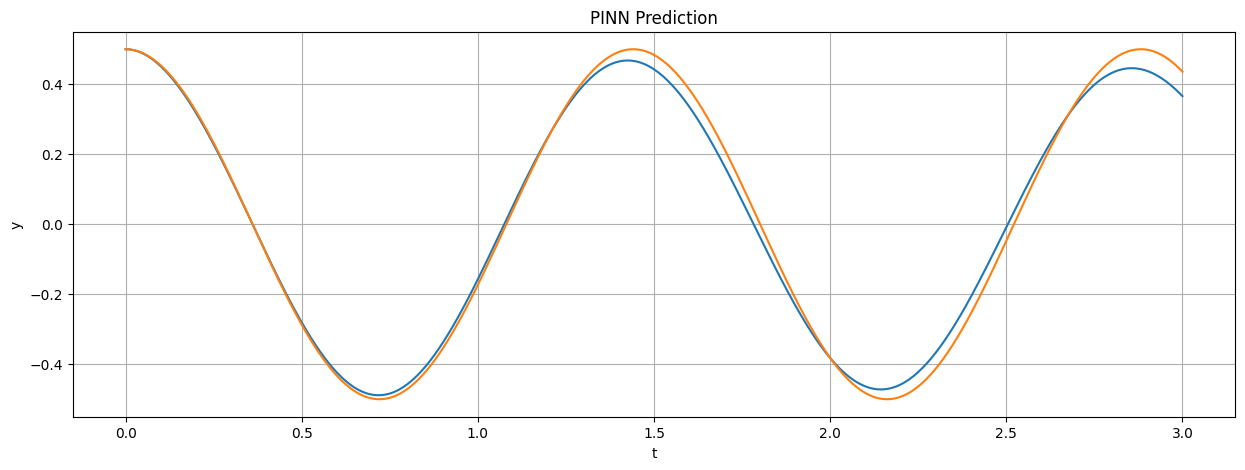

In [18]:
t = torch.linspace(0, t_max, 1000)
plt.figure(figsize=(15, 5))
plt.plot(t.cpu(), model(t.unsqueeze(-1), torch.zeros((1000, 1)), 0.5*torch.ones((1000, 1))).squeeze().detach().cpu())
plt.plot(t.cpu(), sol.y[0])
plt.ylabel("y")
plt.xlabel("t")
plt.title("PINN Prediction")
plt.grid()
plt.show()